# Processamento de Linguagem Natural

In [69]:
from pathlib import Path
import re


from dotenv import load_dotenv
from collections import Counter

import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt

import nltk
from nltk.corpus import stopwords
from gensim import corpora as corpora
from gensim.utils import simple_preprocess
from gensim.models.ldamodel import LdaModel


import spacy
from nltk.stem import PorterStemmer, SnowballStemmer
from numpy.ma.core import left_shift
from seaborn import heatmap

from sklearn.naive_bayes import MultinomialNB
from sklearn.feature_extraction.text import TfidfVectorizer

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

In [2]:
DATASET_DIR = 'dataset'

ROOT_DIR = Path().resolve().__str__()
DATASET_PATH = Path(ROOT_DIR).joinpath(DATASET_DIR)

load_dotenv(ROOT_DIR + 'secrets.env')

False

In [3]:
!kaggle auth login

You are already logged-in to Kaggle as [renataabreu].
Please use the --force flag to override.


In [4]:
import kaggle

kaggle.api.authenticate()
Path.mkdir(Path(DATASET_PATH), parents=True, exist_ok=True)
kaggle.api.dataset_download_files('olistbr/brazilian-ecommerce', path=DATASET_PATH, unzip=True, quiet=False)

print("Path to dataset files: ", DATASET_PATH)

Dataset URL: https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce


100%|██████████| 42.6M/42.6M [00:06<00:00, 7.40MB/s]



Path to dataset files:  C:\Users\Renata\DataspellProjects\Infnet-MIT-IA-PLN-PD_26E2_\dataset


## Normalização

In [5]:
reviews = pd.read_csv(DATASET_PATH.joinpath('olist_order_reviews_dataset.csv'), encoding='utf-8')
geolocation = pd.read_csv(DATASET_PATH.joinpath('olist_geolocation_dataset.csv'), encoding='utf-8')
reviews.dropna(axis=0, subset=['review_comment_message'], inplace=True)
reviews

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53
9,8670d52e15e00043ae7de4c01cc2fe06,b9bf720beb4ab3728760088589c62129,4,recomendo,aparelho eficiente. no site a marca do aparelh...,2018-05-22 00:00:00,2018-05-23 16:45:47
12,4b49719c8a200003f700d3d986ea1a19,9d6f15f95d01e79bd1349cc208361f09,4,NaN,"Mas um pouco ,travando...pelo valor ta Boa.\r\n",2018-02-16 00:00:00,2018-02-20 10:52:22
15,3948b09f7c818e2d86c9a546758b2335,e51478e7e277a83743b6f9991dbfa3fb,5,Super recomendo,"Vendedor confiável, produto ok e entrega antes...",2018-05-23 00:00:00,2018-05-24 03:00:01
...,...,...,...,...,...,...,...
99205,98fffa80dc9acbde7388bef1600f3b15,d398e9c82363c12527f71801bf0e6100,4,NaN,para este produto recebi de acordo com a compr...,2017-11-29 00:00:00,2017-11-30 15:52:51
99208,df5fae90e85354241d5d64a8955b2b09,509b86c65fe4e2ad5b96408cfef9755e,5,NaN,Entregou dentro do prazo. O produto chegou em ...,2018-02-07 00:00:00,2018-02-19 19:47:23
99215,a709d176f59bc3af77f4149c96bae357,d5cb12269711bd1eaf7eed8fd32a7c95,3,NaN,"O produto não foi enviado com NF, não existe v...",2018-05-19 00:00:00,2018-05-20 21:51:06
99221,b3de70c89b1510c4cd3d0649fd302472,55d4004744368f5571d1f590031933e4,5,NaN,"Excelente mochila, entrega super rápida. Super...",2018-03-22 00:00:00,2018-03-23 09:10:43


In [6]:
import numpy as np

nltk.download('stopwords')

stop_words = stopwords.words('portuguese')
stop_words.extend(['nan'])

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Renata\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [7]:
def clean_text_as_list(text):
    tokens = simple_preprocess(str(text), deacc=True, min_len=3)
    return [token for token in tokens if token not in stop_words]

def clean_text_as_str(text):
    tokens = simple_preprocess(str(text), deacc=True, min_len=3)
    return ' '.join((token for token in tokens if token not in stop_words))

Aplica o mesmo preprocessamento, porém o retorno é diferente para uso distintos (_list_ e _string_).

In [8]:
cols = ['review_comment_title', 'review_comment_message']
reviews['tokens'] = (reviews[cols].astype(str)
                     .apply(lambda x:
                                                 ' '.join([str(x['review_comment_title']), str(x['review_comment_message'] if str(x['review_comment_title']) is not None else str(x['review_comment_message']))]), axis=1)
                     .apply(clean_text_as_list))

In [9]:
reviews['review_comment_transformed'] = (reviews[cols].astype(str)
                     .apply(lambda x:
                                ' '.join([str(x['review_comment_title']), str(x['review_comment_message'] if str(x['review_comment_title']) != 'nan' else str(x['review_comment_message']))]), axis=1
                            )
       )

In [10]:
reviews

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,tokens,review_comment_transformed
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06,"[recebi, bem, antes, prazo, estipulado]",nan Recebi bem antes do prazo estipulado.
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53,"[parabens, lojas, lannister, adorei, comprar, ...",nan Parabéns lojas lannister adorei comprar pe...
9,8670d52e15e00043ae7de4c01cc2fe06,b9bf720beb4ab3728760088589c62129,4,recomendo,aparelho eficiente. no site a marca do aparelh...,2018-05-22 00:00:00,2018-05-23 16:45:47,"[recomendo, aparelho, eficiente, site, marca, ...",recomendo aparelho eficiente. no site a marca ...
12,4b49719c8a200003f700d3d986ea1a19,9d6f15f95d01e79bd1349cc208361f09,4,NaN,"Mas um pouco ,travando...pelo valor ta Boa.\r\n",2018-02-16 00:00:00,2018-02-20 10:52:22,"[pouco, travando, valor, boa]","nan Mas um pouco ,travando...pelo valor ta Boa..."
15,3948b09f7c818e2d86c9a546758b2335,e51478e7e277a83743b6f9991dbfa3fb,5,Super recomendo,"Vendedor confiável, produto ok e entrega antes...",2018-05-23 00:00:00,2018-05-24 03:00:01,"[super, recomendo, vendedor, confiavel, produt...","Super recomendo Vendedor confiável, produto ok..."
...,...,...,...,...,...,...,...,...,...
99205,98fffa80dc9acbde7388bef1600f3b15,d398e9c82363c12527f71801bf0e6100,4,NaN,para este produto recebi de acordo com a compr...,2017-11-29 00:00:00,2017-11-30 15:52:51,"[produto, recebi, acordo, compra, realizada]",nan para este produto recebi de acordo com a c...
99208,df5fae90e85354241d5d64a8955b2b09,509b86c65fe4e2ad5b96408cfef9755e,5,NaN,Entregou dentro do prazo. O produto chegou em ...,2018-02-07 00:00:00,2018-02-19 19:47:23,"[entregou, dentro, prazo, produto, chegou, con...",nan Entregou dentro do prazo. O produto chegou...
99215,a709d176f59bc3af77f4149c96bae357,d5cb12269711bd1eaf7eed8fd32a7c95,3,NaN,"O produto não foi enviado com NF, não existe v...",2018-05-19 00:00:00,2018-05-20 21:51:06,"[produto, nao, enviado, nao, existe, venda, ce...","nan O produto não foi enviado com NF, não exis..."
99221,b3de70c89b1510c4cd3d0649fd302472,55d4004744368f5571d1f590031933e4,5,NaN,"Excelente mochila, entrega super rápida. Super...",2018-03-22 00:00:00,2018-03-23 09:10:43,"[excelente, mochila, entrega, super, rapida, s...","nan Excelente mochila, entrega super rápida. S..."


<Axes: >

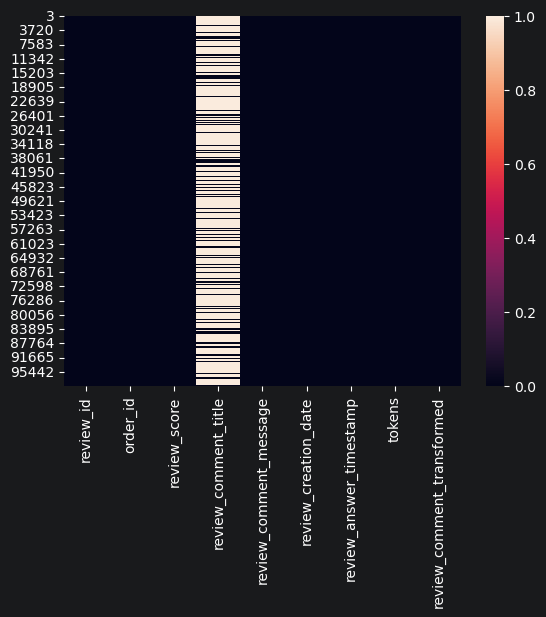

In [11]:
sb.heatmap(reviews.isna())

## Lematização / Stemming

In [12]:
!python -m spacy download pt_core_news_md

     ---------------------------------------- 0.0/42.4 MB ? eta -:--:--
      --------------------------------------- 0.8/42.4 MB 4.2 MB/s eta 0:00:10
     -- ------------------------------------- 2.4/42.4 MB 6.1 MB/s eta 0:00:07
     --- ------------------------------------ 3.7/42.4 MB 6.2 MB/s eta 0:00:07
     ---- ----------------------------------- 5.0/42.4 MB 6.4 MB/s eta 0:00:06
     ----- ---------------------------------- 6.3/42.4 MB 6.3 MB/s eta 0:00:06
     ------ --------------------------------- 7.1/42.4 MB 6.0 MB/s eta 0:00:06
     ------- -------------------------------- 7.9/42.4 MB 5.5 MB/s eta 0:00:07
     ------- -------------------------------- 8.4/42.4 MB 5.3 MB/s eta 0:00:07
     -------- ------------------------------- 8.7/42.4 MB 4.8 MB/s eta 0:00:08
     -------- ------------------------------- 9.2/42.4 MB 4.4 MB/s eta 0:00:08
     --------- ------------------------------ 9.7/42.4 MB 4.2 MB/s eta 0:00:08
     --------- ------------------------------ 10.5/42.4 MB 

In [13]:
snowball_pt = SnowballStemmer(language="portuguese")
nlp_pt = spacy.load("pt_core_news_md")

tokens = []

docs = (reviews['review_comment_transformed'].astype(str)
                    .apply(clean_text_as_str)
       )

for doc in docs:
    lemanizer = nlp_pt(doc)
    for token in lemanizer:
        palavra = token.text.lower()
        stem = snowball_pt.stem(palavra)
        tokens.append({'palavra': palavra,
                           'stemming': stem,
                           'lem': token.lemma_,
                           'classe': token.pos_})

In [14]:
nouns = pd.DataFrame(tokens)
nouns

,palavra,stemming,lem,classe
0,recebi,receb,recebi,VERB
1,bem,bem,bem,ADV
2,antes,antes,antes,ADV
3,prazo,praz,prazo,NOUN
4,estipulado,estipul,estipular,VERB
...,...,...,...,...
309979,pois,pois,pois,ADV
309980,defeito,defeit,defeito,NOUN
309981,nao,nao,nao,ADV
309982,segurar,segur,segurar,VERB


In [15]:
for tuple_tokens in Counter(nouns.palavra).most_common(10):
    print(tuple_tokens)

('produto', 19616)
('nao', 12917)
('prazo', 8598)
('entrega', 7010)
('recomendo', 6064)
('antes', 5680)
('chegou', 5665)
('bom', 5661)
('recebi', 5545)
('entregue', 3939)


## Classificação

### Supervisionada com Naive Bayes e Vetorização com TfidfVectorizer

### Por Categorias

- 1 = Péssimo
- 2 = Ruim
- 3 = Regular
- 4 = Bom
- 5 = Excelente

In [16]:
categories = dict({
    1: 'Péssimo',
    2: 'Ruím',
    3: 'Regular',
    4: 'Bom',
    5: 'Excelente',
})

In [17]:
model = MultinomialNB()
vectorizer = TfidfVectorizer()

X = vectorizer.fit_transform(categories.values())

model.fit(X, list(categories.keys()))

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [18]:
predictions_nm = []
rates_tf_idf = []
for review in docs:
    vec = vectorizer.transform([review])
    rates_tf_idf.append(model.predict(vec)[0])
    # rates_tf_idf.append({"tf-idf": model.predict(vec)[0]})
    predictions_nm.append({"review": review, "nota": model.predict(vec)[0], "categoria": categories.get(model.predict(vec)[0])})


### Por tokens (input dos compradores)

In [19]:
tokens_lem_by_rate = []
tokens_lem = []

_sample = pd.DataFrame(reviews).sample(frac=0.2, random_state=42)

for i, rate in enumerate(categories.keys()):
    filtered = _sample.query('review_score == ' + str(rate))
    for review in pd.DataFrame({'tokens': filtered.review_comment_transformed}).values:
        tokens = clean_text_as_str(review)
        lemanizer = nlp_pt(tokens)
        for lem in lemanizer:
            tokens_lem.append(lem.lemma_)
    tokens_lem_by_rate.append({'rate': rate, 'tokens': tokens_lem.copy()})
    tokens_lem.clear()

In [20]:
model_rate = MultinomialNB()
vectorizer_rate = TfidfVectorizer()

keys = list(pd.DataFrame(tokens_lem_by_rate)['rate'].apply(lambda x: str(x)))
values = list(pd.DataFrame(tokens_lem_by_rate)['tokens'].apply(lambda x: str(x)))
X_rate = vectorizer_rate.fit_transform(values)

model_rate.fit(X_rate, list(keys))

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [21]:
predictions_nm_tokens = []
rates_tf_idf_tokens = []
for review in docs:
    vec = vectorizer_rate.transform([review])
    _X = model_rate.predict(vec)
    rates_tf_idf_tokens.append(int(_X[0]))
    # rates_tf_idf.append({"tf-idf": model.predict(vec)[0]})
    predictions_nm_tokens.append({"review": review, "nota": _X[0], "categoria": categories.get(int(_X[0]))})

### VADER

In [25]:
analyzer = SentimentIntensityAnalyzer()

# adiciona palavras em português
analyzer.lexicon.update({

    "excelente": 5,
    "qualidade": 5,
    "parabens": 5,
    "rapido": 5,
    "recomendar": 5,
    "resistente": 5,
    "otimo": 5,
    "super": 5,

    "bom": 4,
    "recebi": 4,
    "chegou": 4,
    "boa": 4,
    "obrigado": 4,
    "bonito": 4,

    "funcionar": 3,

    "muito ruim": 2,
    "ruim": 2,
    "mal": 2,
    "danificar": 2,
    "defeito": 2,
    "pequeno": 2,

    "pessimo": 1,
    "problema": 1,
    "horrivel": 1,
    "errar": 1,
    "retornar": 1,
    "cancelei": 1,
    "cancelar": 2,
    "reembolso": 1,
    "devolucao": 1,
    "devolver": 1,
})

In [26]:
def compound_to_rating(compound):
    if compound <= -0.6:
        return 1
    elif compound <= -0.2:
        return 2
    elif compound <= 0.2:
        return 3
    elif compound <= 0.6:
        return 4
    else:
        return 5

In [27]:
rates_vader = []
predictions_vader = []
for review in docs:
    vader = analyzer.polarity_scores(review)
    compound = vader['compound']
    rating = compound_to_rating(compound)
    rates_vader.append(rating)

    predictions_vader.append({"review": review, "nota": rating, "categoria": categories.get(rating)})


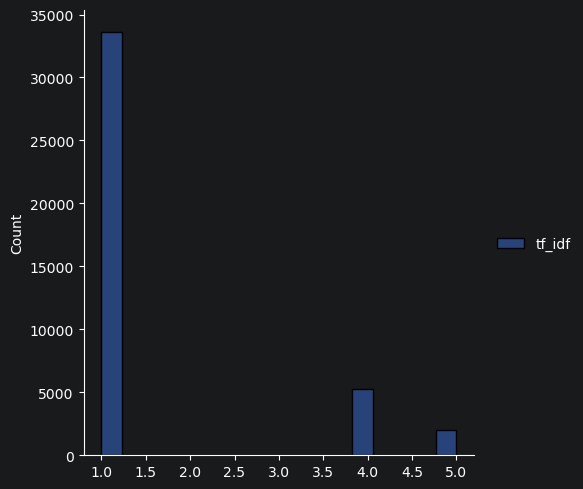

In [28]:
sb.displot(data=pd.DataFrame({'tf_idf': rates_tf_idf}))

In [29]:
pd.DataFrame(predictions_nm)

,review,nota,categoria
0,recebi bem antes prazo estipulado,1,Péssimo
1,parabens lojas lannister adorei comprar intern...,1,Péssimo
2,recomendo aparelho eficiente site marca aparel...,1,Péssimo
3,pouco travando valor boa,1,Péssimo
4,super recomendo vendedor confiavel produto ent...,1,Péssimo
...,...,...,...
40972,produto recebi acordo compra realizada,1,Péssimo
40973,entregou dentro prazo produto chegou condicoes...,1,Péssimo
40974,produto nao enviado nao existe venda certeza f...,1,Péssimo
40975,excelente mochila entrega super rapida super r...,5,Excelente


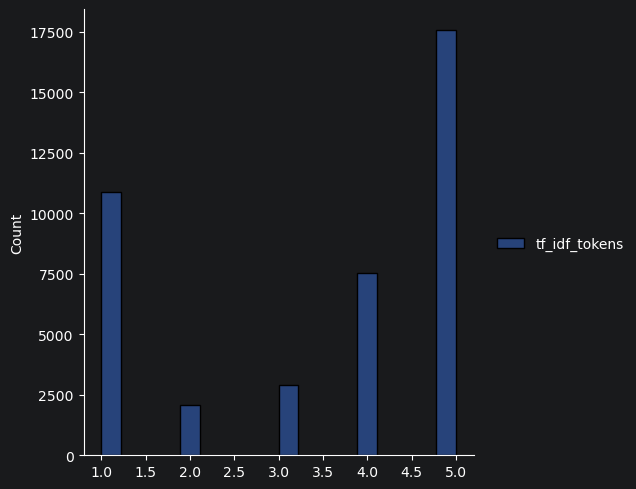

In [30]:
sb.displot(data=pd.DataFrame({'tf_idf_tokens': rates_tf_idf_tokens}))

In [31]:
pd.DataFrame(predictions_nm_tokens).sample(frac=0.2)

,review,nota,categoria
26500,otimo,5,Excelente
4312,produto altissima qualidade super recomendo en...,5,Excelente
31608,bom otimo produto gostei relogio aprovo marca ...,3,Regular
10170,comecei usar produto ontem esperando pra ver r...,3,Regular
2615,fiz compra pedido cabo hdmi vieram separados e...,1,Péssimo
...,...,...,...
14626,gostei produto achei maior deveria informar ta...,2,Ruím
9370,demora resolver problema pois pedido roubado c...,1,Péssimo
12434,super recomendo rapida paralisacao caminhoneir...,1,Péssimo
24295,produto bom menos entrega demorada dentro prazo,4,Bom


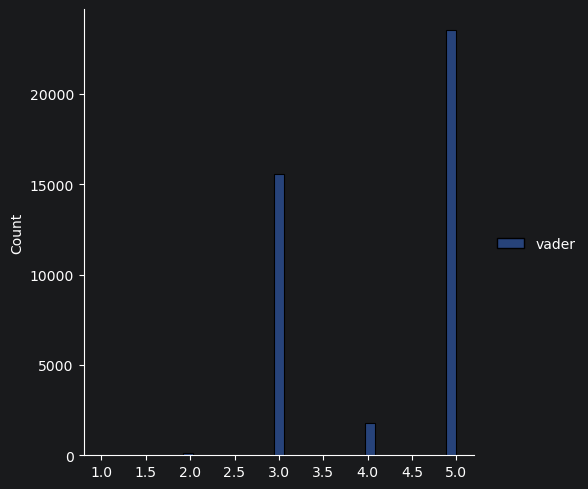

In [32]:
sb.displot(data=pd.DataFrame({'vader': rates_vader}))

In [33]:
pd.DataFrame(predictions_vader).sample(frac=0.5)

,review,nota,categoria
40269,pedi bateria notebook ate agora nada chegar pe...,3,Regular
24034,acho loja maravilhosa tudo agente precisa,3,Regular
13356,comprei escova nao veio mesma comprei site,3,Regular
24658,recomendo entrega feita antes previsto pra dia...,3,Regular
21906,nao recebi porem acredito reflexo greve,5,Excelente
...,...,...,...
17235,chegou prazo atendeu espectativas,5,Excelente
7042,chegou rapido produto dentro especificado,5,Excelente
4411,bom correu tudo conforme combinado,5,Excelente
35442,primeira vez compro site lannister tudo veio c...,5,Excelente


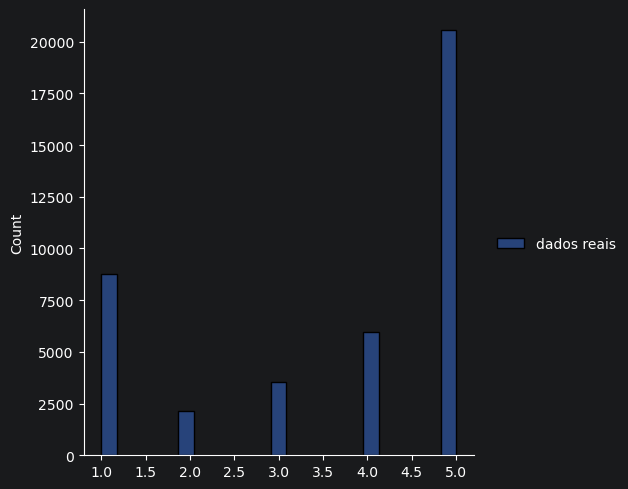

In [34]:
sb.displot(data=pd.DataFrame({'dados reais': reviews.review_score}))

### Comparação

| Método                                             | Análise                                                                                                                                                                                                                |
|----------------------------------------------------|------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| Naive Bayes / TF-IDF por Categoria                 | Não conseguiu categorizar, devido à falta de interpretação léxica e falta de variedade de tokens para categorizar.                                                                                                     |
| Naive Bayes / TF-IDF por Tokens (input de compradores) | Teve boa performance no treinamento, devido aos tokens serem coletados dos próprios compradores para realizar o treinamento, foi possível obter um resultado mais preciso, mesmo com ausência de interpretação léxica. |
| VADER                                              | Teve um desempenho médio, mesmo com a interpretação léxica. A falta de suporte nativo para a lingua portuguesa e a necessidade de input manual dos tokens é um desafio.                                                |

## Extração de Informação

### por Regex

In [105]:
CPF_VALIDATION = "Validação de CPF (proibição)"
EMAIL_VALIDATION = "Validação de E-mail (proibição)"
EXCESSIVE_REPETITION_VALIDATION = "Repetição excessiva"
RATE_IN_REVIEW_VALIDATION = 'Nota dentro do comentário'

matches = []
rules = []
all_matches = []
any_rule = False

for review in reviews.review_comment_message:
    cpf_validation = re.findall(r'/^\d{3}\.\d{3}\.\d{3}\-\d{2}$/', review)                          # Busca CPFs
    email_validation = re.findall(r'/^[a-zA-Z0-9._%+-]+@[a-zA-Z0-9.-]+\.[a-zA-Z]{2,}$/', review)    # Busca e-mails
    excessive_repetition = re.findall(r'(.)\1{3}', review)                                        # Busca excesso de caracteres
    rate_in_review_validation_1 = re.findall(r'^[0-9]', review)                                     # Nota dentro do comentário 1
    rate_in_review_validation_2 = re.findall(r'\bnota\b\s+(\d+)', review, flags=re.IGNORECASE)      # Nota dentro do comentário 2

    if cpf_validation:
        any_rule = True
        matches.extend(cpf_validation)
        rules.append(CPF_VALIDATION)
    if email_validation:
        any_rule = True
        matches.extend(email_validation)
        rules.append(EMAIL_VALIDATION)
    if excessive_repetition:
        any_rule = True
        matches.extend(excessive_repetition)
        rules.append(EXCESSIVE_REPETITION_VALIDATION)
    if rate_in_review_validation_1 or rate_in_review_validation_2:
        if rate_in_review_validation_1:
            matches.extend(rate_in_review_validation_1)
        if rate_in_review_validation_2:
            matches.extend(rate_in_review_validation_2)
        any_rule = True
        rules.append(RATE_IN_REVIEW_VALIDATION)

    if any_rule:
        all_matches.append({'review': review, 'match': matches.copy(), 'rules': rules.copy()})
        any_rule = False
        rules.clear()
        matches.clear()

In [106]:
pd.DataFrame(all_matches)

,review,match,rules
0,Loja nota 10,[10],[Nota dentro do comentário]
1,estao de parabens... sempre chega com muiiita ...,[.],[Repetição excessiva]
2,super rapido a entrega .... chegou antes da da...,[.],[Repetição excessiva]
3,Comprar um produto correto na capa mas interno...,[?],[Repetição excessiva]
4,Cada vez que compro mais fico satisfeita parab...,[👏],[Repetição excessiva]
...,...,...,...
1207,"O produto adquirido não pode ser utilizado, o ...",[.],[Repetição excessiva]
1208,Super recomendo!!!!!,[!],[Repetição excessiva]
1209,sim recebi na cor preta ....queria na cor verm...,[.],[Repetição excessiva]
1210,"Produto foi entregue em tempo ágil, super reco...",[.],[Repetição excessiva]


In [107]:
rule_counter = Counter()
for rules in pd.DataFrame(all_matches)['rules']:
    for rule in rules:
        rule_counter[rule] += 1

pd.DataFrame(rule_counter.most_common())

,0,1
0,Repetição excessiva,915
1,Nota dentro do comentário,309
